# 02 — YouBike Data Cleaning

This notebook uses the reusable pipeline in `src/data_pipeline.py` to validate, normalize, and combine raw YouBike station snapshots.

> Bike-count changes between snapshots are net changes. They can include rentals, returns, redistribution, and data corrections, so they must not be described as observed rental demand.

## 1. Load the reusable pipeline

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

from src.data_pipeline import (
    add_change_features,
    build_quality_summary,
    build_snapshot_summary,
    clean_snapshots,
    discover_snapshot_files,
    load_snapshots,
)

## 2. Discover and load every raw snapshot

In [2]:
raw_directory = project_root / "data" / "raw"
snapshot_files = discover_snapshot_files(raw_directory)
raw_data = load_snapshots(snapshot_files)

print(f"Snapshot files: {len(snapshot_files)}")
print(f"Raw shape: {raw_data.shape}")
snapshot_files

Snapshot files: 2
Raw shape: (3580, 19)


[PosixPath('/Users/xander/Documents/GitHub/youbike-demand-prediction/data/raw/youbike_immediate_sample.json'),
 PosixPath('/Users/xander/Documents/GitHub/youbike-demand-prediction/data/raw/youbike_immediate_sample_02.json')]

## 3. Clean fields and add transparent derived features

In [3]:
clean_data = clean_snapshots(raw_data)
processed_data = add_change_features(clean_data)

display_columns = [
    "snapshot_time",
    "station_id",
    "station_name",
    "capacity",
    "available_bikes",
    "available_return_spaces",
    "unavailable_docks",
    "bike_net_change",
]
processed_data[display_columns].head()

,snapshot_time,station_id,station_name,capacity,available_bikes,available_return_spaces,unavailable_docks,bike_net_change
0,2026-08-20 19:41:52+08:00,500101001,YouBike2.0_捷運科技大樓站,28,24,4,0,NaN
1,2026-08-20 19:56:52+08:00,500101001,YouBike2.0_捷運科技大樓站,28,25,3,0,1.0
2,2026-08-20 19:41:52+08:00,500101002,YouBike2.0_復興南路二段273號前,21,19,1,1,NaN
3,2026-08-20 19:56:52+08:00,500101002,YouBike2.0_復興南路二段273號前,21,19,1,1,0.0
4,2026-08-20 19:41:52+08:00,500101003,YouBike2.0_國北教大實小東側門,28,11,17,0,NaN


## 4. Review data-quality checks

In [4]:
quality_summary = build_quality_summary(
    raw_data, processed_data, snapshot_files
)
quality_summary

,metric,value
0,source_files,2
1,raw_rows,3580
2,processed_rows,3580
3,unique_snapshots,2
4,unique_stations,1790
5,raw_missing_cells,0
6,duplicate_station_snapshot_rows_removed,0
7,inactive_records,58
8,active_empty_records,47
9,active_full_records,41


## 5. Compare snapshots

In [5]:
snapshot_summary = build_snapshot_summary(processed_data)
snapshot_summary

,snapshot_time,station_records,active_stations,total_capacity,available_bikes,return_spaces,unavailable_docks,empty_stations,full_stations,valid_change_intervals,net_bike_change
0,2026-08-20 19:41:52+08:00,1790,1761,50703,21546,27820,1337,24,20,0,0.0
1,2026-08-20 19:56:52+08:00,1790,1761,50703,21345,28032,1326,23,21,1761,-201.0


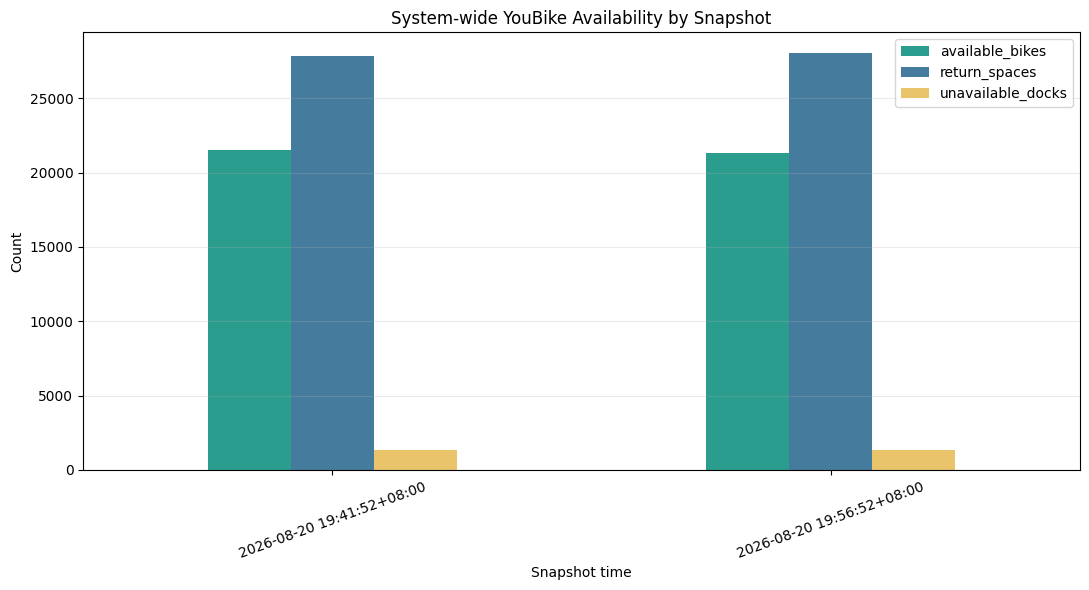

In [6]:
chart_data = snapshot_summary.set_index("snapshot_time")[
    ["available_bikes", "return_spaces", "unavailable_docks"]
]

ax = chart_data.plot(kind="bar", figsize=(11, 6), color=["#2A9D8F", "#457B9D", "#E9C46A"])
ax.set_title("System-wide YouBike Availability by Snapshot")
ax.set_xlabel("Snapshot time")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## Cleaning decisions

- Original JSON files remain unchanged in `data/raw/`.
- API names are mapped to readable analysis names.
- Numeric and timestamp fields are parsed and validated.
- Duplicate station-and-snapshot rows are removed.
- Capacity not represented by bikes or return spaces is retained as `unavailable_docks`; it is not silently discarded.
- Changes are calculated only between consecutive active snapshots.
- More historical snapshots are required before temporal patterns or prediction targets can be evaluated reliably.